# Customer Support Ticket Routing

**Objective:** Route incoming support tickets to the right team with a multiclass NLP model and interpretable terms.

This notebook uses deterministic demo text so the complete workflow runs without private or externally hosted data. Labels are used only for supervised training and evaluation.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the documented demo dataset


In [2]:
TOPICS = {
  "billing": [
    "invoice",
    "refund",
    "charge",
    "payment",
    "subscription",
    "receipt",
    "price",
    "billing"
  ],
  "technical": [
    "error",
    "crash",
    "login",
    "api",
    "timeout",
    "bug",
    "install",
    "technical"
  ],
  "delivery": [
    "shipment",
    "tracking",
    "courier",
    "package",
    "late",
    "address",
    "dispatch",
    "delivery"
  ],
  "account": [
    "profile",
    "password",
    "access",
    "email",
    "security",
    "verification",
    "account",
    "locked"
  ]
}
COMMON_WORDS = ["customer", "service", "today", "online", "request", "information", "please", "system"]
rows = []
for label, vocabulary in TOPICS.items():
    for row_id in range(180):
        signal = rng.choice(vocabulary, size=6, replace=True).tolist()
        context = rng.choice(COMMON_WORDS, size=4, replace=True).tolist()
        other_labels = [name for name in TOPICS if name != label]
        cross_noise = []
        if rng.random() < 0.35:
            other = rng.choice(other_labels)
            cross_noise = rng.choice(TOPICS[other], size=3, replace=True).tolist()
        tokens = signal + context + cross_noise
        rng.shuffle(tokens)
        observed_label = rng.choice(other_labels) if rng.random() < 0.08 else label
        rows.append({"ticket_text": " ".join(tokens), "support_team": observed_label})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head())
display(data["support_team"].value_counts().rename("count").to_frame())


Dataset shape: 720 rows × 2 columns


,ticket_text,support_team
0,service error login customer login login onlin...,technical
1,request today api request today error technica...,technical
2,payment charge price customer price online ple...,billing
3,customer login online technical address courie...,technical
4,courier request package system information tra...,delivery


,count
support_team,
delivery,186
account,183
billing,176
technical,175


## 3. Data quality and exploratory analysis


,dtype,missing,unique
ticket_text,object,0,720
support_team,object,0,4


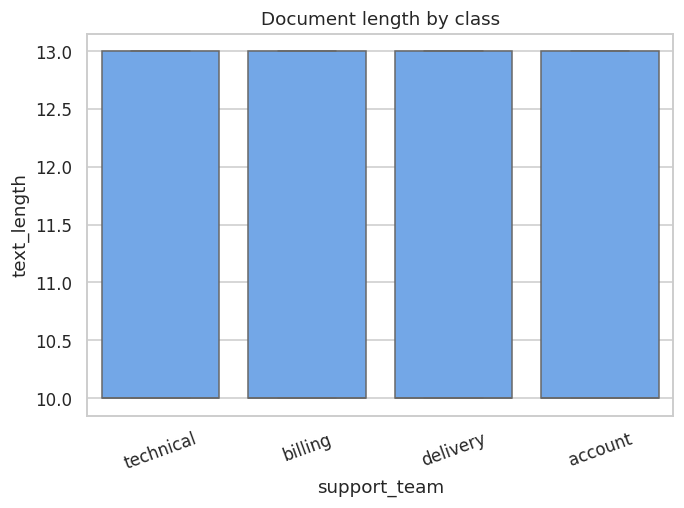

In [3]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(),
})
display(quality)
data["text_length"] = data["ticket_text"].str.split().str.len()
sns.boxplot(data=data, x="support_team", y="text_length", color="#60a5fa")
plt.title("Document length by class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Leakage-safe split, baseline, and candidate models


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    data["ticket_text"], data["support_team"], test_size=0.25,
    random_state=RANDOM_STATE, stratify=data["support_team"],
)
models = {
    "Majority baseline": Pipeline([("tfidf", TfidfVectorizer()), ("model", DummyClassifier(strategy="prior"))]),
    "Multinomial Naive Bayes": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("model", MultinomialNB(alpha=0.6))]),
    "Logistic Regression": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    comparison.append({"model": name, "cv_macro_f1": scores["test_score"].mean(), "cv_std": scores["test_score"].std()})
comparison = pd.DataFrame(comparison).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,model,cv_macro_f1,cv_std
0,Multinomial Naive Bayes,0.9125,0.0095
1,Logistic Regression,0.9125,0.0095
2,Majority baseline,0.1029,0.0000


## 5. Holdout evaluation


Selected model: Multinomial Naive Bayes
Holdout accuracy: 0.9278
Holdout macro F1: 0.9276


,precision,recall,f1-score,support
account,0.8980,0.9565,0.9263,46.0000
billing,0.8800,1.0000,0.9362,44.0000
delivery,1.0000,0.8696,0.9302,46.0000
technical,0.9512,0.8864,0.9176,44.0000
accuracy,0.9278,0.9278,0.9278,0.9278
macro avg,0.9323,0.9281,0.9276,180.0000
weighted avg,0.9327,0.9278,0.9276,180.0000


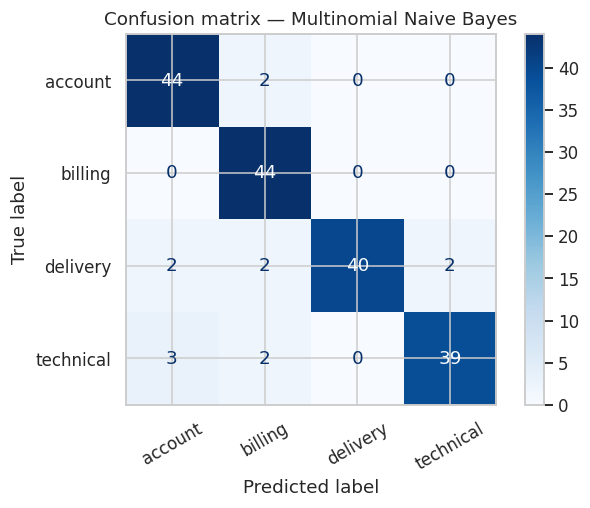

In [5]:
best_name = comparison.iloc[0]["model"]
best_model = models[best_name].fit(X_train, y_train)
predictions = best_model.predict(X_test)
print(f"Selected model: {best_name}")
print(f"Holdout accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Holdout macro F1: {f1_score(y_test, predictions, average='macro'):.4f}")
display(pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).T.round(4))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


## 6. Model interpretation and sample predictions


In [6]:
if best_name == "Logistic Regression":
    vectorizer = best_model.named_steps["tfidf"]
    classifier = best_model.named_steps["model"]
    terms = np.asarray(vectorizer.get_feature_names_out())
    rows = []
    coefficients = classifier.coef_ if len(classifier.classes_) > 2 else np.vstack([-classifier.coef_[0], classifier.coef_[0]])
    for class_name, weights in zip(classifier.classes_, coefficients):
        for term, weight in zip(terms[np.argsort(weights)[-8:]], np.sort(weights)[-8:]):
            rows.append({"class": class_name, "term": term, "weight": weight})
    display(pd.DataFrame(rows).sort_values(["class", "weight"], ascending=[True, False]).round(3))

sample = pd.DataFrame({"text": X_test.iloc[:8], "actual": y_test.iloc[:8], "predicted": predictions[:8]})
display(sample)


,text,actual,predicted
494,receipt receipt please refund refund service p...,billing,billing
197,timeout payment technical request customer log...,technical,technical
495,tracking charge delivery refund online charge ...,billing,billing
587,information locked security system password ve...,account,account
181,online technical timeout customer crash instal...,technical,technical
100,timeout bug online install online technical re...,technical,technical
653,payment customer please system refund subscrip...,billing,billing
564,customer information error error install custo...,technical,technical


## 7. Responsible-use notes and next steps

- Replace deterministic demo text with versioned, licensed, representative data.
- Review class definitions, annotation quality, subgroup performance, and threshold costs with domain experts.
- Keep humans in the loop for hiring, moderation, security, healthcare, finance, and other consequential decisions.
- Monitor vocabulary drift and abstain when confidence or data quality is low.
